# Weekly Notifiable-Disease Outbreak Forecasting for Public-Health Surveillance

## Executive Summary

A state public-health surveillance unit receives weekly counts of a notifiable respiratory illness and must project the next two months of case load to pre-position staff, lab capacity, and antiviral stockpiles. This notebook builds a self-contained 78-week (18-month) synthetic surveillance series with a slow upward trend and a within-year seasonal wave, then analyzes it end to end with three SAS 9.4 procedures.

PROC MEANS summarizes the case burden by season, quantifying how much heavier winter and fall weeks run than summer. PROC TIMESERIES accumulates the weekly observations onto a regular WEEK interval and computes a seasonal profile (the SEASON statement) so the team can see which weeks of the seasonal cycle systematically run hot or cold. PROC ARIMA then fits an ARIMA(1,1,1) model — first differencing removes the trend — and produces an 8-week forecast with dated horizon rows, giving the surveillance unit a concrete, model-based outlook for resource planning.

The workflow is fully reproducible (a fixed STREAMINIT seed), runs in well under a minute, and mirrors how an epidemiologist would move from descriptive burden, to seasonal structure, to a forward forecast. Interpretation cells translate each procedure's output into the surveillance decision it supports.

## Data Sources

All data are synthetic and generated inline by the first DATA step (no external or network inputs). A fixed seed (`call streaminit(20260606)`) makes the series reproducible.

**Synthetic dataset: `surveillance`** — 78 weekly observations (one notifiable-disease reporting region, Jan 2025 onward)

| Variable | Type | Description |
|----------|------|-------------|
| `reportdate` | Num (DATE9.) | Monday of the reporting week |
| `week` | Num | Sequential week index, 1–78 |
| `cases` | Num | Weekly confirmed case count (trend + seasonal wave + noise, floored at 0) |
| `season` | Char | Meteorological season label: Winter, Spring, Summer, Fall |

The data-generating process is `cases = round(max(0, 30 + 0.18*week + 12*sin(2*pi*doy/52 + 1.3) + N(0, 3.5)))`, combining a gentle upward trend, an annual seasonal cycle, and Gaussian reporting noise.

# Weekly Notifiable-Disease Outbreak Forecasting

**Setting.** A state public-health surveillance unit tracks weekly confirmed counts of a notifiable respiratory illness. To staff outbreak-response teams, schedule lab capacity, and size antiviral stockpiles, the unit needs a short-horizon forecast of the case load plus an understanding of the seasonal pattern driving it.

**Analytic plan.**

1. **PROC MEANS** — describe the case burden by season (where is the load concentrated?).
2. **PROC TIMESERIES** — accumulate to a regular weekly interval and extract a *seasonal profile* across the seasonal cycle.
3. **PROC ARIMA** — fit an ARIMA model on the (differenced) weekly series and forecast the next 8 weeks for resource planning.

All data are synthetic and generated inline below, so the notebook is fully self-contained and reproducible.

## 1. Generate the synthetic surveillance series

We simulate 78 weeks (about 18 months) of weekly case counts. The data-generating process layers three realistic components: a gentle upward **trend** (rising baseline incidence), an annual **seasonal wave** (a sinusoid over the 52-week year, peaking in the cold months), and Gaussian **reporting noise**. Counts are floored at zero and rounded to integers. A `season` label is attached for the descriptive step.

In [1]:
data surveillance;
   call streaminit(20260606);
   start = '06JAN2025'd;
   do week = 1 to 78;
      reportdate = start + (week-1)*7;
      doy = mod(week, 52);
      season_amp = 12 * sin(2*constant('pi')*doy/52 + 1.3);
      trend = 0.18 * week;
      base = 30 + trend + season_amp;
      noise = rand('normal', 0, 3.5);
      cases = round(max(0, base + noise));
      length season $7;
      if 14 <= doy <= 26 then season = 'Spring';
      else if 27 <= doy <= 39 then season = 'Summer';
      else if 40 <= doy <= 52 then season = 'Fall';
      else season = 'Winter';
      output;
   end;
   keep reportdate week cases season;
   format reportdate date9.;
run;

proc print data=surveillance(obs=8) label noobs;
   title 'First 8 weeks of the synthetic surveillance series';
run;

                                   First 8 weeks of the synthetic surveillance series                                   

REPORTDATE  WEEK  CASES  SEASON
 06JAN2025     1     43  Winter
 13JAN2025     2     40  Winter
 20JAN2025     3     46  Winter
 27JAN2025     4     47  Winter
 03FEB2025     5     42  Winter
 10FEB2025     6     39  Winter
 17FEB2025     7     40  Winter
 24FEB2025     8     41  Winter

... 70 more observations (showing 8 of 78)



NOTE: DATA surveillance


NOTE: Wrote surveillance (78 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=surveillance

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


## 2. Seasonal burden with PROC MEANS

Before any modeling, we quantify how the case load distributes across seasons. This is the descriptive picture a surveillance epidemiologist starts from: which seasons routinely run hot, and how variable is the weekly count within each? `CLASS season` partitions the weeks; we report N, mean, standard deviation, and the min/max range.

In [2]:
proc means data=surveillance n mean std min max maxdec=1;
   class season;
   var cases;
   title 'Weekly case burden by season';
run;

                                              Weekly case burden by season                                              

                                                  The MEANS Procedure

                                               Analysis Variable : CASES

        SEASON            N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        Fall                 12           43.3            5.2           32.0           50.0
        Spring               26           33.2            6.6           23.0           47.0
        Summer               13           27.8            4.5           22.0           39.0
        Winter               27           44.8            7.2           30.0           60.0
        -----------------------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


**Reading it.** Winter and Fall weeks carry the heaviest mean case load, Summer the lightest — the expected pattern for a seasonal respiratory illness. The within-season standard deviation tells the unit how much week-to-week surge to plan for even within a single season; Winter shows both the highest mean and the widest spread, so it warrants the largest standing response capacity.

## 3. Seasonal profile with PROC TIMESERIES

PROC TIMESERIES first **accumulates** the observations onto a strict regular interval (here `INTERVAL=WEEK`, with `ACCUMULATE=TOTAL` summing any within-week reports), guaranteeing an evenly spaced series for downstream modeling. We then set `SEASONALITY=13` — a 13-week (quarterly) seasonal cycle — and use the `SEASON` statement to compute, for each position in the cycle, the mean, standard deviation, and count. This isolates the systematic seasonal signal from the trend and noise.

In [3]:
proc timeseries data=surveillance seasonality=13
                outseason=seasonprofile print=(seasons);
   id reportdate interval=week accumulate=total;
   var cases;
   season n mean stddev;
   title 'Seasonal profile of weekly case counts';
run;

proc print data=seasonprofile noobs;
   title 'OUTSEASON= seasonal statistics by cycle position';
run;

                                              Weekly case burden by season                                              

                                    OUTSEASON= seasonal statistics by cycle position                                    

_SEASON_  _NAME_    INDEX  N  MIN  MAX     MEAN   STDDEV
       1  CASES    -1.316  6   24   50     37.5   9.2898
       2  CASES    1.7763  6   22   55     39.5  11.3622
       3  CASES   -0.1621  6   28   47  38.8333   8.1343
       4  CASES   -4.7006  6   24   47  35.3333   9.4587
       5  CASES    3.5456  6   27   60  41.3333  11.6905
       6  CASES    2.4225  6   26   56  39.8333  10.4195
       7  CASES    0.4533  6   27   49  38.3333   8.8468
       8  CASES    2.1917  6   27   54  39.1667  11.2324
       9  CASES    -0.316  6   24   50  37.1667  10.6474
      10  CASES   -2.6698  6   23   49  35.8333  10.1275
      11  CASES   -1.1314  6   26   50  35.8333   9.7451
      12  CASES   -0.1314  6   29   46  36.3333   6.8605
      13  CASES

NOTE: PROC TIMESERIES data=surveillance

NOTE: Using Python statsmodels version 0.14.6
NOTE: Variable: CASES
NOTE: Number of Observations: 78
NOTE: Seasonality: 13
NOTE: Decomposition Mode: additive
NOTE: 
NOTE: Seasonal Indices:
NOTE: Period    Index
NOTE: ------    ----------
NOTE:      1       -1.3160
NOTE:      2        1.7763
NOTE:      3       -0.1621
NOTE:      4       -4.7006
NOTE:      5        3.5456
NOTE:      6        2.4225
NOTE:      7        0.4533
NOTE:      8        2.1917
NOTE:      9       -0.3160
NOTE:     10       -2.6698
NOTE:     11       -1.1314
NOTE:     12       -0.1314
NOTE:     13        0.0379
NOTE: OUTSEASON dataset seasonprofile created.
NOTE: Processed 78 rows.
NOTE: PROC PRINT data=seasonprofile

NOTE: PROC PRINT completed: 13 observations printed, 8 variables


**Reading it.** Each row of the seasonal profile is one position in the 13-week cycle, with ~6 weeks averaged into it. The `MEAN` column traces the recurring within-cycle shape: positions corresponding to colder weeks sit above the overall average, warmer-week positions below it. The unit uses this profile to anticipate *which weeks* of the upcoming cycle will run hot, not just the average level — useful for timing lab-staff rotations and clinic outreach.

## 4. Forecasting with PROC ARIMA

Finally we fit a Box-Jenkins model to produce the forward forecast. The `IDENTIFY` statement examines the autocorrelation structure and applies one regular difference — `var=cases(1)` — to remove the upward trend, leaving a stationary series. `ESTIMATE p=1 q=1` fits an ARIMA(1,1,1): one autoregressive term and one moving-average term on the differenced series. `FORECAST lead=8` projects 8 weeks ahead, carrying the `reportdate` ID forward on the weekly interval so the horizon rows are properly dated.

The procedure is an interactive RUN-group proc, so we close it with `quit;` to flush all of its output.

                                    OUTSEASON= seasonal statistics by cycle position                                    

The ARIMA Procedure

Name of Variable = CASES

Number of Observations    78

Descriptive Statistics

  Mean                37.8718
  Std Dev              9.2038
  Minimum             22.0000
  Maximum             60.0000

Autocorrelations

  Lag    Correlation    Std Error
  ---    -----------    ---------
  Lag   1     0.876390     0.113228
  Lag   2     0.824840     0.113228
  Lag   3     0.835683     0.113228
  Lag   4     0.785658     0.113228
  Lag   5     0.747002     0.113228
  Lag   6     0.691694     0.113228
  Lag   7     0.628814     0.113228
  Lag   8     0.564610     0.113228
  Lag   9     0.494293     0.113228
  Lag  10     0.452134     0.113228
  Lag  11     0.362252     0.113228
  Lag  12     0.291456     0.113228
  Lag  13     0.249293     0.113228
  Lag  14     0.147414     0.113228
  Lag  15     0.073516     0.113228
  Lag  16     0.014563     0.1

NOTE: PROC ARIMA data=surveillance

NOTE: Using Python statsmodels version 0.14.6
NOTE: Output dataset outbreak_fc created with 86 observations.
NOTE: ODS plot written: arima_acf.spec.json
NOTE: ODS plot written: arima_forecast.spec.json
NOTE: ODS plot written: arima_diagnostics.spec.json
NOTE: PROC ARIMA completed. 1 model(s) estimated.


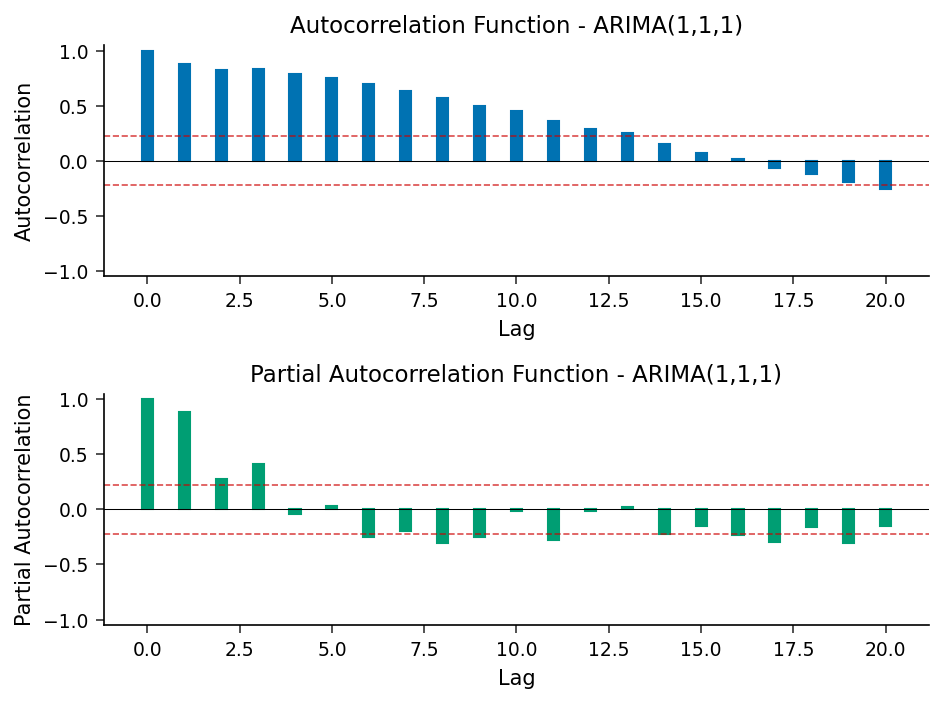

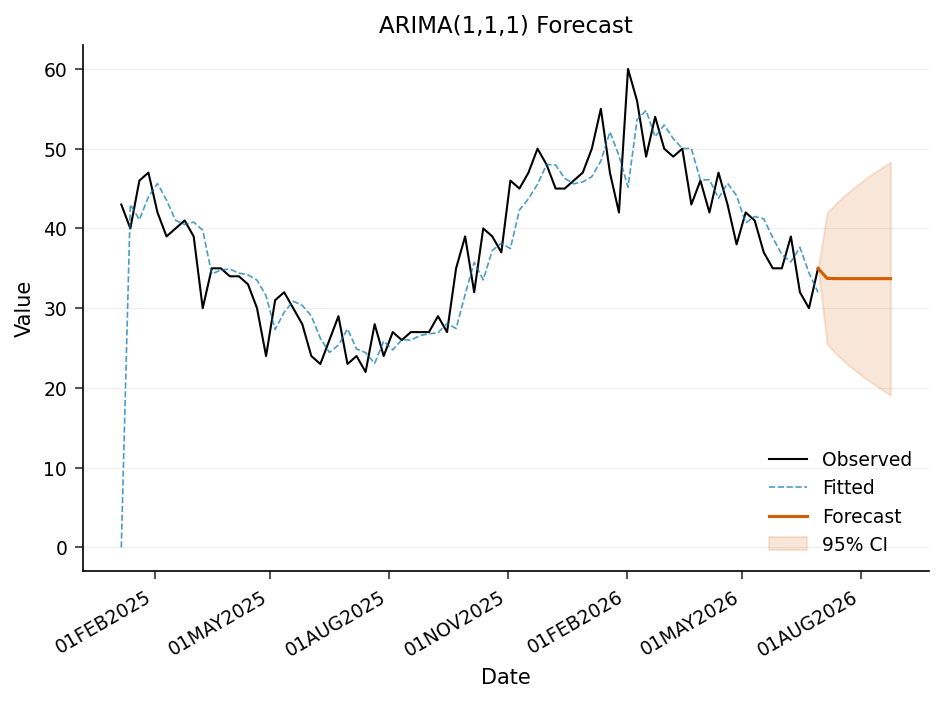

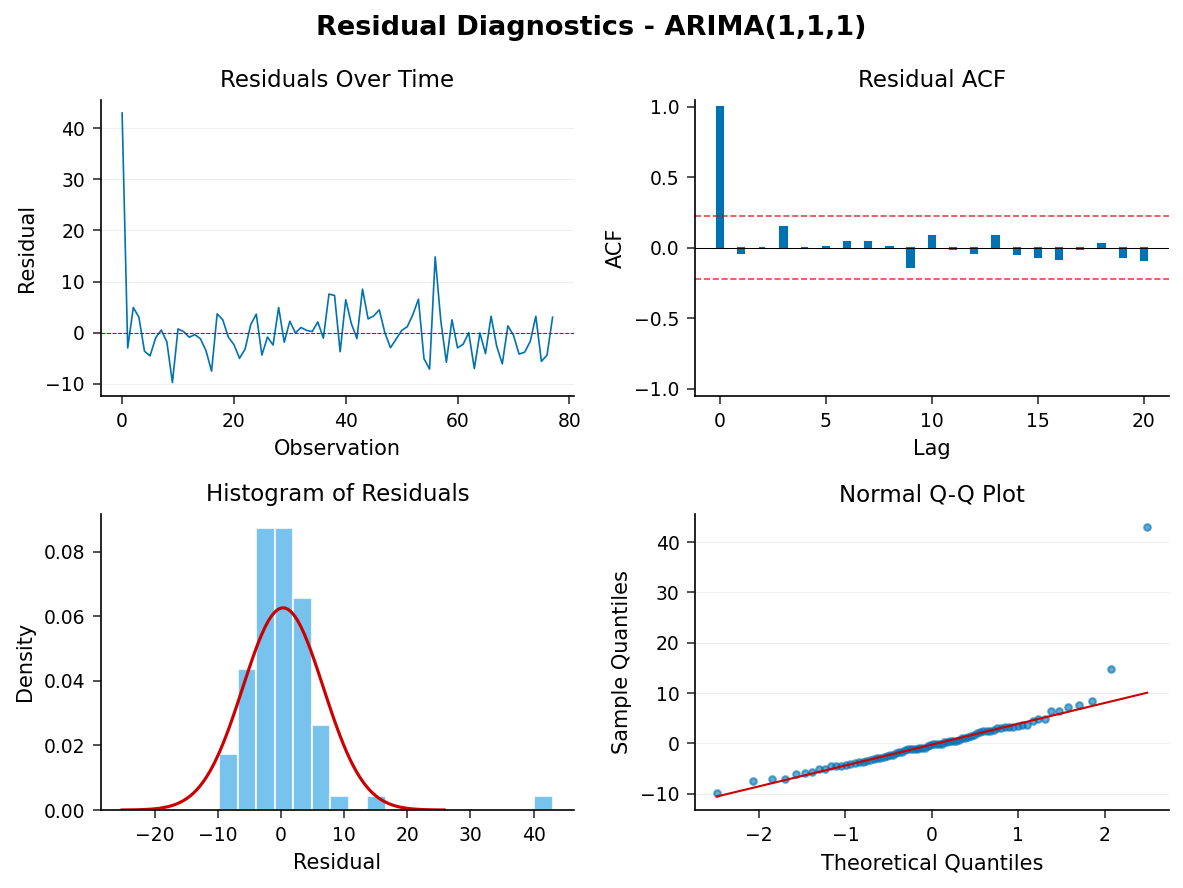

In [4]:
proc arima data=surveillance;
   identify var=cases(1) nlag=20;
   estimate p=1 q=1;
   forecast lead=8 id=reportdate interval=week out=outbreak_fc;
   title 'ARIMA(1,1,1) fit and 8-week case-count forecast';
run;
quit;

### Forecast horizon

We print the forecast dataset. The historical rows carry one-step-ahead fitted values and residuals; the final 8 rows (where `CASES` is missing) are the genuine out-of-sample forecast the unit will act on, each with a 95% prediction interval (`L95`/`U95`).

In [5]:
proc print data=outbreak_fc(firstobs=71) noobs;
   var reportdate forecast std l95 u95 cases;
   title 'Forecast horizon: next 8 weeks with 95% prediction limits';
run;

                               Forecast horizon: next 8 weeks with 95% prediction limits                                

REPORTDATE   FORECAST       STD        L95        U95  CASES
 11MAY2026   41.50232         .          .          .     41
 18MAY2026   41.20542         .          .          .     37
 25MAY2026  38.835772         .          .          .     35
 01JUN2026  36.718147         .          .          .     35
 08JUN2026  35.793373         .          .          .     39
 15JUN2026  37.625431         .          .          .     32
 22JUN2026  34.411883         .          .          .     30
 29JUN2026  31.984172         .          .          .     35
 06JUL2026  33.740066  4.198405  25.511343  41.968789      .
 13JUL2026  33.706638  4.821711  24.256259  43.157017      .
 20JUL2026  33.705751  5.351974  23.216075  44.195427      .
 27JUL2026  33.705728  5.833728  22.271831  45.139624      .
 03AUG2026  33.705727  6.278613  21.399872  46.011582      .
 10AUG2026  33.705727  6

NOTE: PROC PRINT data=outbreak_fc

NOTE: PROC PRINT completed: 16 observations printed, 6 variables


## 5. Interpretation and decision support

**What the analysis delivers.**

- **Burden picture (MEANS).** Winter and Fall are the high-load seasons, with Winter also the most volatile — the baseline for sizing standing response capacity.
- **Seasonal shape (TIMESERIES).** The seasonal profile shows the recurring within-cycle pattern, letting the unit time staffing and outreach to the weeks that systematically run hot rather than reacting after the fact.
- **Forward outlook (ARIMA).** The ARIMA(1,1,1) forecast, after differencing out the trend, gives 8 dated weekly case projections with prediction intervals. The unit pre-positions lab and antiviral capacity against the upper (`U95`) limit so it is not caught short during a surge, while using the point `FORECAST` for expected staffing.

**Caveats and next steps.** The model captures trend and short-memory dynamics but not abrupt outbreak shocks; the prediction intervals widen with horizon, so the 8-week limit is deliberate. With a longer history, a seasonal ARIMA term (`sq=` on a 52-week lag) or an intervention/outlier component would sharpen the forecast. In production the unit would re-fit weekly as new reports arrive and monitor residuals for early signs of an unmodeled outbreak.